In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report
import warnings
warnings.filterwarnings("ignore")

Read Data

In [168]:
df_data = pd.read_csv("E:\Projects SIC\Project 2\combinenew.csv")
df_data.shape

(2830744, 79)

Show Data

In [169]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.00,2.00,0.00,12.00,0.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
1,55054,109.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
2,55055,52.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
3,46236,34.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
4,54863,3.00,2.00,0.00,12.00,0.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN


Information About Data And Describe Data

In [170]:
df_data.info(show_counts=True)
# Target => Label => Str
# Destination Port => Object 
# Remaining Data => Float


<class 'pandas.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             2830744 non-null  object 
 1    Flow Duration                2830743 non-null  float64
 2    Total Fwd Packets            2830743 non-null  float64
 3    Total Backward Packets       2830743 non-null  float64
 4   Total Length of Fwd Packets   2830743 non-null  float64
 5    Total Length of Bwd Packets  2830743 non-null  float64
 6    Fwd Packet Length Max        2830743 non-null  float64
 7    Fwd Packet Length Min        2830743 non-null  float64
 8    Fwd Packet Length Mean       2830743 non-null  float64
 9    Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max         2830743 non-null  float64
 11   Bwd Packet Length Min        2830743 non-null  float64
 12   Bwd Packet Length Mean       2830743 n

In [171]:
pd.set_option('display.float_format', lambda x: '%.2f' % x) # So We Can See The Data Clearly.
df_data.describe() # Data Need Scaling

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,...,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00
mean,14785663.93,9.36,10.39,549.30,16162.64,207.60,18.71,58.20,68.91,870.85,...,5.42,-2741.69,81551.32,41134.12,153182.52,58295.82,8316036.63,503843.95,8695751.98,7920031.01
std,33653744.09,749.67,997.39,9993.59,2263088.05,717.18,60.34,186.09,281.19,1946.37,...,636.43,1084989.38,648599.94,393381.52,1025824.97,577092.28,23630078.58,4602984.48,24366888.33,23363418.93
min,-13.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,-536870661.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,155.00,2.00,1.00,12.00,0.00,6.00,0.00,6.00,0.00,0.00,...,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,31316.00,2.00,2.00,62.00,123.00,37.00,2.00,34.00,0.00,79.00,...,1.00,24.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3204828.50,5.00,4.00,187.00,482.00,81.00,36.00,50.00,26.16,280.00,...,2.00,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,119999998.00,219759.00,291922.00,12900000.00,655453030.00,24820.00,2325.00,5940.86,7125.60,19530.00,...,213557.00,138.00,110000000.00,74200000.00,110000000.00,110000000.00,120000000.00,76900000.00,120000000.00,120000000.00


Check About Dublicates

In [172]:
df_data.duplicated().sum()

np.int64(330406)

There is 330406 duplicated we will remove 

In [173]:
df_data.drop_duplicates(inplace=True) # Drop Duplicates

df_data.duplicated().sum() # Check Again

np.int64(0)

In [174]:
df_data.shape # The Shape Data After Drop Duplicates

(2500338, 79)

Check Null Values

In [175]:
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)
df_data.replace(['?', 'unknown', 'Unknown', 'UNKNOWN', 'None', 'none', ' '], np.nan, inplace=True)
print(df_data.isnull().sum().to_string())

 Destination Port                  0
 Flow Duration                     1
 Total Fwd Packets                 1
 Total Backward Packets            1
Total Length of Fwd Packets        1
 Total Length of Bwd Packets       1
 Fwd Packet Length Max             1
 Fwd Packet Length Min             1
 Fwd Packet Length Mean            1
 Fwd Packet Length Std             1
Bwd Packet Length Max              1
 Bwd Packet Length Min             1
 Bwd Packet Length Mean            1
 Bwd Packet Length Std             1
Flow Bytes/s                    1542
 Flow Packets/s                 1538
 Flow IAT Mean                     1
 Flow IAT Std                      1
 Flow IAT Max                      1
 Flow IAT Min                      1
Fwd IAT Total                      1
 Fwd IAT Mean                      1
 Fwd IAT Std                       1
 Fwd IAT Max                       1
 Fwd IAT Min                       1
Bwd IAT Total                      1
 Bwd IAT Mean                      1
 

Null Values Is Very Low We Will Drop it

In [176]:
df_data.dropna(inplace=True)
# Check 
print(df_data.isnull().sum().to_string())

 Destination Port               0
 Flow Duration                  0
 Total Fwd Packets              0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Mean         0
 Fwd Packet Length Std          0
Bwd Packet Length Max           0
 Bwd Packet Length Min          0
 Bwd Packet Length Mean         0
 Bwd Packet Length Std          0
Flow Bytes/s                    0
 Flow Packets/s                 0
 Flow IAT Mean                  0
 Flow IAT Std                   0
 Flow IAT Max                   0
 Flow IAT Min                   0
Fwd IAT Total                   0
 Fwd IAT Mean                   0
 Fwd IAT Std                    0
 Fwd IAT Max                    0
 Fwd IAT Min                    0
Bwd IAT Total                   0
 Bwd IAT Mean                   0
 Bwd IAT Std                    0
 Bwd IAT Max                    0
 Bwd IAT Min  

In [177]:
# Destination Port => object , but we want it to be int.
df_data.columns = df_data.columns.str.strip()
df_data['Destination Port'] = pd.to_numeric(df_data['Destination Port'], errors='coerce')
df_data.dropna(subset=['Destination Port'], inplace=True)
df_data['Destination Port'] = df_data['Destination Port'].astype(int)


df_data.reset_index(drop=True, inplace=True)

print(df_data['Destination Port'].dtype)
print("Shape:", df_data.shape)

int64
Shape: (2498796, 79)


Remove Columns ALL Zero's And Data Leakage

In [178]:
df_data.columns = df_data.columns.str.strip()
col_zero = [
    "Destination Port", # Data Leakage
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bytes/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bulk Rate",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd URG Flags",
    "CWE Flag Count"
]
df_data[col_zero].replace(0, np.nan).isnull().sum()

Destination Port           1565
Fwd Avg Packets/Bulk    2498796
Fwd Avg Bytes/Bulk      2498796
Bwd Avg Packets/Bulk    2498796
Bwd Avg Bytes/Bulk      2498796
Fwd Avg Bulk Rate       2498796
Bwd Avg Bulk Rate       2498796
Bwd PSH Flags           2498796
Bwd URG Flags           2498796
Fwd URG Flags           2498716
CWE Flag Count          2498716
dtype: int64

In [179]:
df_data.drop(columns=col_zero, inplace=True)
print("Shape:", df_data.shape)

Shape: (2498796, 68)


Check Class Distribution (Label)

In [180]:
label_counts = df_data['Label'].value_counts()
label_percentage = df_data['Label'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({'Count': label_counts, 'Percentage': label_percentage.round(3)})
print(distribution)

                            Count  Percentage
Label                                        
BENIGN                    2073053       82.96
DoS Hulk                   172846        6.92
DDoS                       128016        5.12
PortScan                    90694        3.63
DoS GoldenEye               10286        0.41
FTP-Patator                  5931        0.24
DoS slowloris                5385        0.22
DoS Slowhttptest             5228        0.21
SSH-Patator                  3219        0.13
Bot                          1948        0.08
Web Attack_Brute Force       1470        0.06
Web Attack_XSS                652        0.03
Infiltration                   36        0.00
Web Attack_Sql Injection       21        0.00
Heartbleed                     11        0.00


The dataset is highly imbalanced (BENIGN dominates)

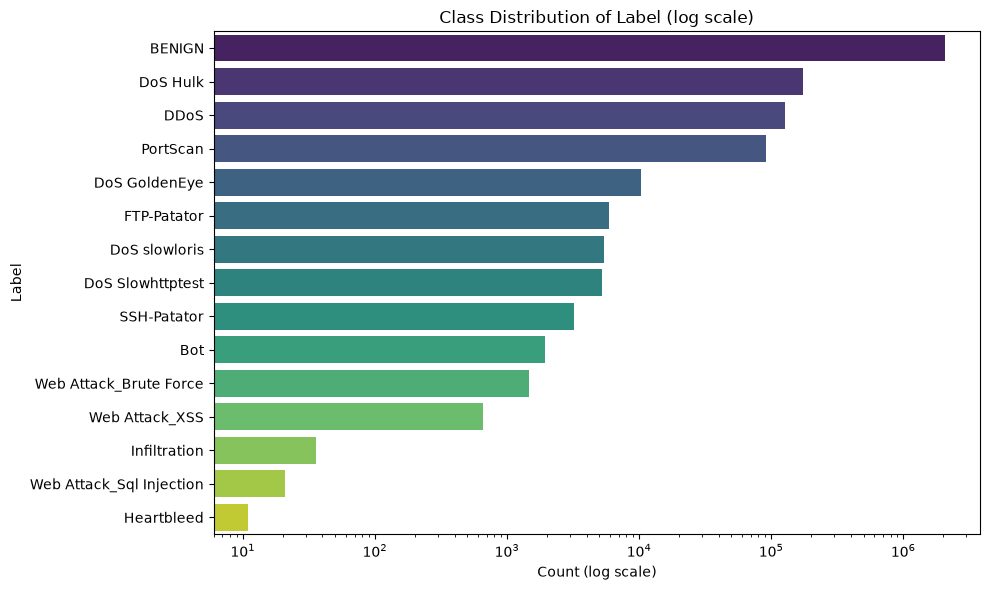

In [181]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('Label')
plt.title('Class Distribution of Label (log scale)')
plt.tight_layout()
plt.show()

Encode categorical labels to numeric values

In [182]:
le = LabelEncoder()
df_data['Label_Encoded'] = le.fit_transform(df_data['Label'])


Map to Binary (0: BENIGN, 1: ATTACK)

In [183]:
df_data['Binary_Label'] = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

Feature & Target Split

In [184]:
X = df_data.drop(columns=['Label', 'Label_Encoded', 'Binary_Label'])
y = df_data['Binary_Label']

In [185]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [186]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (1999036, 67), X_test shape: (499760, 67)


Feature Scaling
- Fit on train set, transform both train and test to prevent data leakage


In [187]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Final Cleaned Data Overview

In [188]:
print("Final shape:", df_data.shape)
df_data.head()

Final shape: (2498796, 70)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label_Encoded,Binary_Label
0,3.00,2.00,0.00,12.00,0.00,6.00,6.00,6.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN,0,0
1,109.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,6.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN,0,0
2,52.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,6.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN,0,0
3,34.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,6.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN,0,0
4,3.00,2.00,0.00,12.00,0.00,6.00,6.00,6.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN,0,0
